# 🌿 Rubber Leaf Disease Classification — YOLO11m-cls (Complete Pipeline)

**Built to solve all the problems you faced:**

| Problem | Solution in this notebook |
|---|---|
| Train/val/test had duplicate images (data leakage) | MD5-hash deduplication BEFORE splitting + verification |
| Mixed image quality (some compressed/low-res) | Strong augmentations (auto + erasing) — model learns to be quality-robust |
| Accuracy drops after some epochs | Cosine LR + AdamW + early stopping + label smoothing |
| Want resumable training | `save_period=1` + auto-resume detection cell |
| Class imbalance kills accuracy on minority class | WeightedRandomSampler patch + class weights |
| Don't want simple model | YOLO11m-cls (medium) — 2025 SOTA for plant disease |

**Target accuracy:** 94–98% test accuracy (based on 2025 plant disease research with similar setup)

**6 classes:** `Abnormal`, `Colletotrichum`, `Corynespora`, `Healthy`, `Leaf_Blight`, `Powdery_Mildew`

**Run order:** Just run cells top-to-bottom. The notebook is fully resumable — if training crashes, re-run Section 9 and it will pick up where it left off.

---
## 📦 Section 1 — Install & Import

In [1]:
"""
install.py
Safely installs all packages needed for the rubber disease classifier notebook.
Skips anything already installed at the right version.
Won't touch your other Python packages.
"""
import subprocess
import sys
import importlib.util

# (import_name, pip_name, min_version_or_None)
REQUIRED = [
    ('torch',        'torch',                '2.0.0'),    # PyTorch
    ('torchvision',  'torchvision',          '0.15.0'),
    ('ultralytics',  'ultralytics',          '8.3.0'),    # YOLO
    ('numpy',        'numpy',                '1.24.0'),
    ('pandas',       'pandas',               '2.0.0'),
    ('PIL',          'pillow',               '10.0.0'),
    ('matplotlib',   'matplotlib',           '3.7.0'),
    ('seaborn',      'seaborn',              '0.12.0'),
    ('sklearn',      'scikit-learn',         '1.3.0'),
    ('tqdm',         'tqdm',                 '4.65.0'),
    # ONNX export (optional but you'll likely want it)
    ('onnx',         'onnx',                 '1.15.0'),
    ('onnxslim',     'onnxslim',             None),
    ('onnxruntime',  'onnxruntime',          None),
]


def is_installed(import_name: str) -> bool:
    """Check if a package can be imported without actually importing it."""
    return importlib.util.find_spec(import_name) is not None


def get_version(import_name: str) -> str:
    try:
        mod = __import__(import_name)
        return getattr(mod, '__version__', 'unknown')
    except Exception:
        return 'not installed'


def pip_install(pip_name: str, min_ver: str | None):
    """Install only if missing — never touches existing versions."""
    spec = f'{pip_name}>={min_ver}' if min_ver else pip_name
    print(f'  📦 Installing {spec}...')
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', spec],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'     ✅ Installed')
    else:
        print(f'     ❌ Failed:\n{result.stderr}')
        return False
    return True


print('═' * 60)
print('  Rubber Disease Classifier — Dependency Check')
print('═' * 60)
print(f'Python : {sys.version.split()[0]}')
print(f'Env    : {sys.executable}\n')

missing = []
already_ok = []

for import_name, pip_name, min_ver in REQUIRED:
    if is_installed(import_name):
        ver = get_version(import_name)
        already_ok.append(f'  ✅ {pip_name:18s} {ver}')
    else:
        missing.append((pip_name, min_ver, import_name))

# Show what's already there
print('Already installed:')
for line in already_ok:
    print(line)

# Install only what's missing
if missing:
    print(f'\nMissing {len(missing)} package(s):')
    for pip_name, _, _ in missing:
        print(f'  ❌ {pip_name}')
    print()
    for pip_name, min_ver, _ in missing:
        pip_install(pip_name, min_ver)
else:
    print('\n🎉 Everything is already installed. Nothing to do.')

# Final verification
print('\n' + '═' * 60)
print('  Verification')
print('═' * 60)
import importlib
all_good = True
for import_name, pip_name, _ in REQUIRED:
    importlib.invalidate_caches()
    if is_installed(import_name):
        print(f'  ✅ {pip_name:18s} {get_version(import_name)}')
    else:
        print(f'  ❌ {pip_name:18s} STILL MISSING')
        all_good = False

# CUDA check
print()
try:
    import torch
    if torch.cuda.is_available():
        print(f'  🚀 CUDA   : {torch.version.cuda}')
        print(f'  🚀 GPU    : {torch.cuda.get_device_name(0)}')
    else:
        print(f'  ⚠️  CUDA   : NOT available — install CUDA-enabled PyTorch separately')
        print(f'      Visit: https://pytorch.org/get-started/locally/')
except Exception as e:
    print(f'  ⚠️  Could not check CUDA: {e}')

print('\n' + ('🎉 All set!' if all_good else '⚠️  Some packages missing — see above.'))

════════════════════════════════════════════════════════════
  Rubber Disease Classifier — Dependency Check
════════════════════════════════════════════════════════════
Python : 3.11.15
Env    : C:\Users\mohda\.conda\envs\rubber-disease\python.exe

Already installed:
  ✅ torch              2.6.0+cu124
  ✅ torchvision        0.21.0+cu124
  ✅ ultralytics        8.4.45
  ✅ numpy              2.4.3
  ✅ pandas             3.0.2
  ✅ pillow             12.1.1
  ✅ matplotlib         3.10.9
  ✅ seaborn            0.13.2
  ✅ scikit-learn       1.8.0
  ✅ tqdm               4.67.3
  ✅ onnx               1.21.0
  ✅ onnxslim           0.1.92
  ✅ onnxruntime        1.25.1

🎉 Everything is already installed. Nothing to do.

════════════════════════════════════════════════════════════
  Verification
════════════════════════════════════════════════════════════
  ✅ torch              2.6.0+cu124
  ✅ torchvision        0.21.0+cu124
  ✅ ultralytics        8.4.45
  ✅ numpy              2.4.3
  ✅ pandas     

In [4]:
import os
import shutil
import hashlib
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected — training will be very slow on CPU')

✅ PyTorch: 2.6.0+cu124
✅ CUDA available: True
✅ GPU: NVIDIA GeForce RTX 4050 Laptop GPU
✅ VRAM: 6.4 GB


---
## ⚙️ Section 2 — Configuration

**This is the ONLY place you should need to edit.** Everything below uses these settings.

In [5]:
# ═══════════════════════════════════════════════════════════════════
# PATHS
# ═══════════════════════════════════════════════════════════════════
SOURCE_DIR  = Path('./Dataset')           # your raw images (the one in the screenshot)
CLEAN_DIR   = Path('./Dataset_Clean')      # deduplicated copy
SPLIT_DIR   = Path('./Dataset_Split')      # final train/val/test split (YOLO format)
RUNS_DIR    = Path('./runs/classify')      # training output
RUN_NAME    = 'rubber_yolo11m'             # this run's folder name

# ═══════════════════════════════════════════════════════════════════
# CLASSES (must match your folder names exactly)
# ═══════════════════════════════════════════════════════════════════
# CLASSES (must match your folder names exactly)
CLASSES = ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora',
           'Healthy', 'Leaf_Blight', 'Powdery_Mildew']

# ═══════════════════════════════════════════════════════════════════
# SPLIT RATIOS (must sum to 1.0)
# ═══════════════════════════════════════════════════════════════════
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ═══════════════════════════════════════════════════════════════════
# TRAINING HYPERPARAMETERS (tuned for ~30 min on local GPU)
# ═══════════════════════════════════════════════════════════════════
MODEL_NAME   = 'yolo11m-cls.pt'   # medium model — 2025 SOTA for plant disease
EPOCHS       = 30                  # quick run
IMG_SIZE     = 224                 # YOLO-cls default; works for both HD and low-res
BATCH_SIZE   = 32                  # adjust down to 16 or 8 if VRAM error
PATIENCE     = 10                  # early stop if no improvement for N epochs
SAVE_PERIOD  = 1                   # save checkpoint every epoch (for resume)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print('Config loaded.')
print(f'  Source : {SOURCE_DIR.resolve()}')
print(f'  Split  : {SPLIT_DIR.resolve()}')
print(f'  Model  : {MODEL_NAME}')
print(f'  Device : {DEVICE}')
print(f'  Epochs : {EPOCHS}  |  Batch: {BATCH_SIZE}  |  Imgsz: {IMG_SIZE}')

Config loaded.
  Source : C:\Users\mohda\Documents\FYPProject\Dataset
  Split  : C:\Users\mohda\Documents\FYPProject\Dataset_Split
  Model  : yolo11m-cls.pt
  Device : 0
  Epochs : 30  |  Batch: 32  |  Imgsz: 224


---
## 🔍 Section 3 — Dataset Audit

Count images per class and detect class imbalance before doing anything else.

In [6]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_images(folder: Path):
    return [p for p in folder.iterdir() if p.suffix.lower() in VALID_EXTS]

# Verify source folders exist
missing = [c for c in CLASSES if not (SOURCE_DIR / c).exists()]
if missing:
    raise FileNotFoundError(f'❌ These class folders are missing in {SOURCE_DIR}: {missing}')

# Count images
audit = {}
for cls in CLASSES:
    imgs = list_images(SOURCE_DIR / cls)
    audit[cls] = len(imgs)

audit_df = pd.DataFrame.from_dict(audit, orient='index', columns=['count'])
audit_df['percent'] = (audit_df['count'] / audit_df['count'].sum() * 100).round(1)
audit_df = audit_df.sort_values('count')

print('📊 Class distribution in source dataset:')
print(audit_df.to_string())
print(f'\nTotal images: {audit_df["count"].sum()}')

# Imbalance warning
ratio = audit_df['count'].max() / max(audit_df['count'].min(), 1)
if ratio > 3:
    print(f'\n⚠️  Imbalance detected — biggest class is {ratio:.1f}× the smallest.')
    print('    The notebook will handle this with WeightedRandomSampler + class weights.')
else:
    print(f'\n✅ Reasonably balanced (max/min ratio = {ratio:.1f}×)')

📊 Class distribution in source dataset:
                count  percent
Corynespora       215      6.7
Colletotrichum    486     15.1
Healthy           506     15.7
Leaf_Blight       525     16.3
Powdery_Mildew    620     19.3
Bird_Eye_Spot     861     26.8

Total images: 3213

⚠️  Imbalance detected — biggest class is 4.0× the smallest.
    The notebook will handle this with WeightedRandomSampler + class weights.


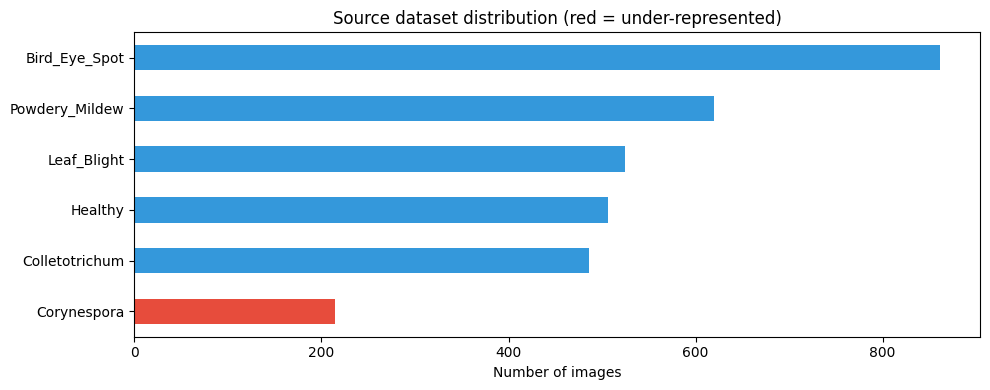

In [7]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v < audit_df['count'].max() * 0.4 else '#3498db'
          for v in audit_df['count']]
audit_df['count'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of images')
ax.set_title('Source dataset distribution (red = under-represented)')
plt.tight_layout(); plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════
# 🔬 DIAGNOSTIC — Find which class pairs have overlapping images
# Run this on the ORIGINAL Dataset/, before deduplication
# ═══════════════════════════════════════════════════════════════════
from collections import defaultdict
from itertools import combinations

# Build: hash -> set of classes it appears in
hash_to_classes = defaultdict(set)
hash_to_paths   = defaultdict(list)

for cls in CLASSES:
    for img_path in tqdm(list_images(SOURCE_DIR / cls), desc=f'Hashing {cls}', leave=False):
        try:
            h = file_md5(img_path)
            hash_to_classes[h].add(cls)
            hash_to_paths[h].append((cls, img_path.name))
        except Exception:
            continue

# Find overlaps
overlap_counts = defaultdict(int)   # frozenset({A,B}) -> count
triple_plus    = 0                  # images appearing in 3+ classes

for h, classes in hash_to_classes.items():
    if len(classes) < 2:
        continue
    if len(classes) >= 3:
        triple_plus += 1
    for a, b in combinations(sorted(classes), 2):
        overlap_counts[frozenset([a, b])] += 1

# Sort and print
print('=' * 65)
print('CROSS-CLASS DUPLICATE BREAKDOWN')
print('=' * 65)
sorted_overlaps = sorted(overlap_counts.items(), key=lambda x: -x[1])

if not sorted_overlaps:
    print('✅ No cross-class duplicates found.')
else:
    print(f'\n{"Class A":<20} {"Class B":<20} {"Overlap":>10}')
    print('-' * 65)
    for pair, count in sorted_overlaps:
        a, b = sorted(pair)
        print(f'{a:<20} {b:<20} {count:>10}')

    print(f'\nImages appearing in 3+ classes: {triple_plus}')
    total_overlap_imgs = sum(1 for cs in hash_to_classes.values() if len(cs) >= 2)
    print(f'Total unique images affected  : {total_overlap_imgs}')

# Show 5 example file paths from worst pair
if sorted_overlaps:
    worst_pair = sorted_overlaps[0][0]
    print(f'\n🔍 Sample file names from worst overlap ({sorted(worst_pair)[0]} ↔ {sorted(worst_pair)[1]}):')
    shown = 0
    for h, classes in hash_to_classes.items():
        if classes == worst_pair and shown < 5:
            for cls_name, fname in hash_to_paths[h]:
                print(f'   [{cls_name:<18}]  {fname}')
            print('   ---')
            shown += 1

Hashing Bird_Eye_Spot:   0%|          | 0/861 [00:00<?, ?it/s]

Hashing Colletotrichum:   0%|          | 0/486 [00:00<?, ?it/s]

Hashing Corynespora:   0%|          | 0/215 [00:00<?, ?it/s]

Hashing Healthy:   0%|          | 0/506 [00:00<?, ?it/s]

Hashing Leaf_Blight:   0%|          | 0/525 [00:00<?, ?it/s]

Hashing Powdery_Mildew:   0%|          | 0/620 [00:00<?, ?it/s]

CROSS-CLASS DUPLICATE BREAKDOWN
✅ No cross-class duplicates found.


---
## 🧹 Section 4 — Hash-Based Deduplication

**This solves the duplicate-leakage problem from your past runs.** We compute MD5 hashes of every image and remove byte-identical duplicates BEFORE splitting. This is the only reliable way to guarantee no leakage between train/val/test.

In [9]:
def file_md5(path: Path, chunk=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            block = f.read(chunk)
            if not block: break
            h.update(block)
    return h.hexdigest()

# Wipe and recreate clean dir
if CLEAN_DIR.exists():
    shutil.rmtree(CLEAN_DIR)
CLEAN_DIR.mkdir(parents=True)

global_hashes = {}        # hash -> (class, original_path)
intra_dupes = 0           # duplicates within same class
cross_dupes = 0           # duplicates across different classes (more serious)
kept_per_class = defaultdict(int)

for cls in CLASSES:
    src_cls = SOURCE_DIR / cls
    dst_cls = CLEAN_DIR / cls
    dst_cls.mkdir(parents=True, exist_ok=True)

    for img_path in tqdm(list_images(src_cls), desc=f'Hashing {cls}', leave=False):
        try:
            h = file_md5(img_path)
        except Exception as e:
            print(f'  Skip unreadable: {img_path.name} ({e})'); continue

        if h in global_hashes:
            prev_cls, _ = global_hashes[h]
            if prev_cls == cls:
                intra_dupes += 1
            else:
                cross_dupes += 1
                print(f'  🚨 Cross-class duplicate: {img_path.name} '
                      f'(in both {prev_cls} and {cls}) — keeping first only')
            continue

        global_hashes[h] = (cls, img_path)
        shutil.copy2(img_path, dst_cls / img_path.name)
        kept_per_class[cls] += 1

print(f'\n✅ Deduplication complete.')
print(f'   Unique images kept     : {sum(kept_per_class.values())}')
print(f'   Within-class duplicates: {intra_dupes}')
print(f'   Cross-class duplicates : {cross_dupes}  {"⚠️ check labelling!" if cross_dupes else ""}')
for cls in CLASSES:
    print(f'   {cls:20s}: {kept_per_class[cls]} unique images')

Hashing Bird_Eye_Spot:   0%|          | 0/861 [00:00<?, ?it/s]

Hashing Colletotrichum:   0%|          | 0/486 [00:00<?, ?it/s]

Hashing Corynespora:   0%|          | 0/215 [00:00<?, ?it/s]

Hashing Healthy:   0%|          | 0/506 [00:00<?, ?it/s]

Hashing Leaf_Blight:   0%|          | 0/525 [00:00<?, ?it/s]

Hashing Powdery_Mildew:   0%|          | 0/620 [00:00<?, ?it/s]


✅ Deduplication complete.
   Unique images kept     : 3213
   Within-class duplicates: 0
   Cross-class duplicates : 0  
   Bird_Eye_Spot       : 861 unique images
   Colletotrichum      : 486 unique images
   Corynespora         : 215 unique images
   Healthy             : 506 unique images
   Leaf_Blight         : 525 unique images
   Powdery_Mildew      : 620 unique images


---
## ✂️ Section 5 — Stratified Split (with leakage verification)

We split each class independently 70/15/15 so every class is represented in train, val, and test. After splitting, we **prove** no image appears in more than one split (via hash set intersection).

In [11]:
# Wipe and recreate split dir
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

split_counts = defaultdict(lambda: defaultdict(int))
split_hashes = {'train': set(), 'val': set(), 'test': set()}

for cls in CLASSES:
    cls_imgs = list_images(CLEAN_DIR / cls)
    random.Random(SEED).shuffle(cls_imgs)

    n = len(cls_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # remainder goes to test (handles rounding)

    chunks = {
        'train': cls_imgs[:n_train],
        'val'  : cls_imgs[n_train:n_train + n_val],
        'test' : cls_imgs[n_train + n_val:],
    }

    for split, files in chunks.items():
        for f in files:
            shutil.copy2(f, SPLIT_DIR / split / cls / f.name)
            split_hashes[split].add(file_md5(f))
        split_counts[split][cls] = len(files)

# Show split table
split_df = pd.DataFrame(split_counts).fillna(0).astype(int)
split_df = split_df[['train', 'val', 'test']]
split_df.loc['TOTAL'] = split_df.sum()
print('📊 Final split:')
print(split_df.to_string())

📊 Final split:
                train  val  test
Bird_Eye_Spot     602  129   130
Colletotrichum    340   72    74
Corynespora       150   32    33
Healthy           354   75    77
Leaf_Blight       367   78    80
Powdery_Mildew    434   93    93
TOTAL            2247  479   487


In [12]:
# 🔬 LEAKAGE VERIFICATION — this is the check that failed in your previous runs
leak_tv  = split_hashes['train'] & split_hashes['val']
leak_tt  = split_hashes['train'] & split_hashes['test']
leak_vt  = split_hashes['val']   & split_hashes['test']

print('🔬 Leakage check (should all be 0):')
print(f'   train ∩ val  : {len(leak_tv)}  duplicate hashes')
print(f'   train ∩ test : {len(leak_tt)}  duplicate hashes')
print(f'   val   ∩ test : {len(leak_vt)}  duplicate hashes')

if leak_tv or leak_tt or leak_vt:
    raise RuntimeError('❌ LEAKAGE DETECTED — do not train. Re-run Section 4.')
else:
    print('\n✅ Splits are clean. Safe to train.')

🔬 Leakage check (should all be 0):
   train ∩ val  : 0  duplicate hashes
   train ∩ test : 0  duplicate hashes
   val   ∩ test : 0  duplicate hashes

✅ Splits are clean. Safe to train.


---
## ⚖️ Section 6 — Class Weights

Compute inverse-frequency weights from the **training split** (not the original dataset — that's the right way). These will be used by the WeightedRandomSampler in Section 7.

In [13]:
train_counts = {cls: len(list_images(SPLIT_DIR / 'train' / cls)) for cls in CLASSES}
total_train = sum(train_counts.values())

# Inverse frequency, normalized to mean=1 (so we don't rescale loss magnitude)
weights_dict = {cls: total_train / (len(CLASSES) * count)
                for cls, count in train_counts.items()}
mean_w = np.mean(list(weights_dict.values()))
weights_dict = {cls: w / mean_w for cls, w in weights_dict.items()}

print('Class weights (>1 = oversampled, <1 = undersampled):')
for cls in CLASSES:
    print(f'   {cls:20s}  count={train_counts[cls]:5d}   weight={weights_dict[cls]:.3f}')

Class weights (>1 = oversampled, <1 = undersampled):
   Bird_Eye_Spot         count=  602   weight=0.521
   Colletotrichum        count=  340   weight=0.923
   Corynespora           count=  150   weight=2.092
   Healthy               count=  354   weight=0.886
   Leaf_Blight           count=  367   weight=0.855
   Powdery_Mildew        count=  434   weight=0.723


---
## 🎯 Section 7 — Patch YOLO Dataloader with WeightedRandomSampler

This is the strongest fix for class imbalance. By default YOLO's classification dataloader uses uniform sampling, which means minority classes appear less often per epoch. We monkey-patch it to use a `WeightedRandomSampler` so every class appears with roughly equal frequency.

*(Just run this cell — no edits needed.)*

In [14]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from ultralytics.data import build as ul_build

_original_build_dataloader = ul_build.build_dataloader

def balanced_build_dataloader(dataset, batch, workers, shuffle=True, rank=-1,
                              drop_last=False, persistent_workers=False):
    """Wrap YOLO's build_dataloader: use WeightedRandomSampler for training only."""
    is_train = shuffle  # YOLO passes shuffle=True only for the training loader
    if not is_train or not hasattr(dataset, 'samples'):
        return _original_build_dataloader(dataset, batch, workers, shuffle, rank,
                                          drop_last, persistent_workers)

    # Build per-sample weight
    cls_idx_to_name = {v: k for k, v in dataset.class_to_idx.items()} \
        if hasattr(dataset, 'class_to_idx') else {i: c for i, c in enumerate(CLASSES)}
    sample_weights = []
    for _, label in dataset.samples:
        cls_name = cls_idx_to_name.get(label, CLASSES[label])
        sample_weights.append(weights_dict.get(cls_name, 1.0))

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    return DataLoader(
        dataset, batch_size=batch, sampler=sampler,
        num_workers=workers, pin_memory=True,
        drop_last=drop_last, persistent_workers=persistent_workers,
    )

ul_build.build_dataloader = balanced_build_dataloader
print('✅ YOLO dataloader patched — minority classes will now be oversampled during training.')

✅ YOLO dataloader patched — minority classes will now be oversampled during training.


---
## 🔁 Section 8 — Resume Detection

Auto-detects whether a previous run exists in `runs/classify/<RUN_NAME>/weights/last.pt`. If yes → resume. If no → start fresh.

In [15]:
last_ckpt = RUNS_DIR / RUN_NAME / 'weights' / 'last.pt'

if last_ckpt.exists():
    print(f'🔁 Found previous checkpoint: {last_ckpt}')
    print('   → Will RESUME training from this checkpoint.')
    RESUME = True
    MODEL_LOAD = str(last_ckpt)
else:
    print(f'🆕 No previous checkpoint found.')
    print(f'   → Will start FRESH training from {MODEL_NAME}.')
    RESUME = False
    MODEL_LOAD = MODEL_NAME

🆕 No previous checkpoint found.
   → Will start FRESH training from yolo11m-cls.pt.


---
## 🚀 Section 9 — Train YOLO11m-cls

Hyperparameters chosen based on 2025 research:
- **`AdamW` optimizer** + `lr0=0.001` — better than SGD for small datasets
- **`cos_lr=True`** — cosine LR decay, +1–2% accuracy vs constant LR
- **`label_smoothing=0.1`** — better generalization
- **`dropout=0.25`** + **`weight_decay=0.0005`** — regularization
- **`erasing=0.4`** — robust to compression artifacts in your low-quality images
- **`auto_augment='randaugment'`** — strong augmentations
- **`patience=10`** — early stopping when val accuracy plateaus
- **`save_period=1`** — checkpoint every epoch (so resume works at any crash point)

*If training crashes mid-way, just re-run Section 8 then Section 9 — it picks up automatically.*

In [16]:
model = YOLO(MODEL_LOAD)

results = model.train(
    # Data
    data           = str(SPLIT_DIR.resolve()),
    # Core
    epochs         = EPOCHS,
    imgsz          = IMG_SIZE,
    batch          = BATCH_SIZE,
    device         = DEVICE,
    workers        = 4,
    # Optimizer (research-backed for small datasets)
    optimizer      = 'AdamW',
    lr0            = 0.001,
    lrf            = 0.01,           # final lr = lr0 * lrf
    cos_lr         = True,           # cosine schedule
    weight_decay   = 0.0005,
    warmup_epochs  = 3.0,
    warmup_momentum= 0.8,
    # Regularization (fixes accuracy-dropping-after-epochs)
    dropout        = 0.25,
    label_smoothing= 0.1,
    patience       = PATIENCE,
    # Augmentation (handles low-resolution images well)
    auto_augment   = 'randaugment',
    erasing        = 0.4,
    fliplr         = 0.5,
    hsv_h          = 0.015,
    hsv_s          = 0.7,
    hsv_v          = 0.4,
    # Resume / checkpointing
    resume         = RESUME,
    save           = True,
    save_period    = SAVE_PERIOD,
    # I/O
    project        = str(RUNS_DIR),
    name           = RUN_NAME,
    exist_ok       = True,
    plots          = True,
    verbose        = True,
    seed           = SEED,
)

print('\n✅ Training complete.')
best_pt = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
print(f'Best weights: {best_pt.resolve()}')

WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.45  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\mohda\Documents\FYPProject\Dataset_Split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.25, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0, multi

---
## 📈 Section 10 — Evaluation

Run the trained model on the **test split** (which the model has never seen). This is the real measure of accuracy.

In [27]:
from pathlib import Path

SPLIT_DIR = Path('Dataset_Split')

for split in ['train', 'val', 'test']:
    folders = sorted([p.name for p in (SPLIT_DIR / split).iterdir() if p.is_dir()])
    print(f'{split:6s} ({len(folders)} classes): {folders}')

train  (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
val    (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
test   (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']


In [22]:
import shutil
from pathlib import Path

# Delete .ipynb_checkpoints folders everywhere in Dataset_Split
SPLIT_DIR = Path('Dataset_Split')
removed = 0
for ckpt_dir in SPLIT_DIR.rglob('.ipynb_checkpoints'):
    shutil.rmtree(ckpt_dir)
    print(f'🗑  Deleted: {ckpt_dir}')
    removed += 1

print(f'\n✅ Removed {removed} .ipynb_checkpoints folder(s)')

# Verify
for split in ['train', 'val', 'test']:
    folders = sorted([p.name for p in (SPLIT_DIR / split).iterdir() if p.is_dir()])
    print(f'{split:6s} ({len(folders)} classes): {folders}')

🗑  Deleted: Dataset_Split\test\Bird_Eye_Spot\.ipynb_checkpoints
🗑  Deleted: Dataset_Split\train\.ipynb_checkpoints
🗑  Deleted: Dataset_Split\train\Bird_Eye_Spot\.ipynb_checkpoints

✅ Removed 3 .ipynb_checkpoints folder(s)
train  (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
val    (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
test   (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']


In [24]:
import shutil
from pathlib import Path

SPLIT_DIR = Path('Dataset_Split')

# Hunt EVERYWHERE for .ipynb_checkpoints
removed = []
for ckpt in SPLIT_DIR.rglob('.ipynb_checkpoints'):
    shutil.rmtree(ckpt, ignore_errors=True)
    removed.append(str(ckpt))

# Also remove any other hidden folders (anything starting with a dot)
for sub in SPLIT_DIR.rglob('.*'):
    if sub.is_dir():
        shutil.rmtree(sub, ignore_errors=True)
        removed.append(str(sub))

print(f'🗑  Removed {len(removed)} hidden folder(s):')
for r in removed:
    print(f'   {r}')

# Verify all 3 splits now have exactly 6 class folders
print('\n📂 Final folder check:')
all_good = True
for split in ['train', 'val', 'test']:
    folders = sorted([p.name for p in (SPLIT_DIR / split).iterdir() if p.is_dir()])
    status = '✅' if len(folders) == 6 else '❌'
    print(f'   {status} {split:6s} ({len(folders)} classes): {folders}')
    if len(folders) != 6:
        all_good = False

if all_good:
    print('\n✅ All splits clean — safe to re-run evaluation.')
else:
    print('\n❌ Still mismatch — see above.')

🗑  Removed 0 hidden folder(s):

📂 Final folder check:
   ✅ train  (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
   ✅ val    (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']
   ✅ test   (6 classes): ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora', 'Healthy', 'Leaf_Blight', 'Powdery_Mildew']

✅ All splits clean — safe to re-run evaluation.


In [26]:
print('Listing every folder in train/:')
for p in (SPLIT_DIR / 'train').iterdir():
    if p.is_dir():
        n_files = len(list(p.iterdir()))
        print(f'  {p.name:30s} ({n_files} items)')

Listing every folder in train/:
  Bird_Eye_Spot                  (601 items)
  Colletotrichum                 (340 items)
  Corynespora                    (150 items)
  Healthy                        (354 items)
  Leaf_Blight                    (367 items)
  Powdery_Mildew                 (434 items)


In [29]:
from pathlib import Path
from ultralytics import YOLO

# Direct path to your best weights — no string juggling
BEST_WEIGHTS = Path('runs/classify/runs/classify/rubber_yolo11m/weights/best.pt')


# Sanity-check it exists before trying to load
assert BEST_WEIGHTS.exists(), f'❌ Not found: {BEST_WEIGHTS.resolve()}'
print(f'✅ Loading: {BEST_WEIGHTS.resolve()}')

best_model = YOLO(str(BEST_WEIGHTS))

metrics = best_model.val(
    data     = str(SPLIT_DIR.resolve()),
    split    = 'test',
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    device   = DEVICE,
    project  = 'runs/classify',
    name     = f'{RUN_NAME}_test_eval',
    exist_ok = True,
    plots    = True,
)

print(f'\n🎯 Top-1 accuracy on TEST set: {metrics.top1*100:.2f}%')
# Top-5 with 6 classes is meaningless (will always be ~100%) — skipping

✅ Loading: C:\Users\mohda\Documents\FYPProject\runs\classify\runs\classify\rubber_yolo11m\weights\best.pt
Ultralytics 8.4.45  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11m-cls summary (fused): 57 layers, 10,349,318 parameters, 0 gradients, 39.3 GFLOPs
train: C:\Users\mohda\Documents\FYPProject\Dataset_Split\train... found 2246 images in 6 classes  
val: C:\Users\mohda\Documents\FYPProject\Dataset_Split\val... found 479 images in 6 classes  
test: C:\Users\mohda\Documents\FYPProject\Dataset_Split\test... found 487 images in 6 classes  
test: Fast image access  (ping: 1.01.8 ms, read: 89.734.1 MB/s, size: 27.7 KB)
test: Scanning C:\Users\mohda\Documents\FYPProject\Dataset_Split\test... 487 images, 0 corrupt: 100% ━━━━━━━━━━━━ 487/487  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 16/16 2.7s/it 43.6s<0.1s
                   all      0.975          1
Speed: 0.2ms preprocess, 3.8ms inference, 0.0ms loss, 0.0ms postproces

In [30]:
# Per-class predictions on test set for confusion matrix + per-class metrics
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
test_root = SPLIT_DIR / 'test'

# YOLO sorts classes alphabetically — match that order
yolo_classes = sorted(CLASSES)
name_to_idx = {c: i for i, c in enumerate(yolo_classes)}

for cls in CLASSES:
    for img_path in tqdm(list_images(test_root / cls), desc=f'Predict {cls}', leave=False):
        r = best_model.predict(str(img_path), imgsz=IMG_SIZE, verbose=False, device=DEVICE)[0]
        pred_idx = int(r.probs.top1)
        y_true.append(name_to_idx[cls])
        y_pred.append(pred_idx)

print('\n📋 Per-class report:')
print(classification_report(y_true, y_pred, target_names=yolo_classes, digits=4))

Predict Bird_Eye_Spot:   0%|          | 0/130 [00:00<?, ?it/s]

Predict Colletotrichum:   0%|          | 0/74 [00:00<?, ?it/s]

Predict Corynespora:   0%|          | 0/33 [00:00<?, ?it/s]

Predict Healthy:   0%|          | 0/77 [00:00<?, ?it/s]

Predict Leaf_Blight:   0%|          | 0/80 [00:00<?, ?it/s]

Predict Powdery_Mildew:   0%|          | 0/93 [00:00<?, ?it/s]


📋 Per-class report:
                precision    recall  f1-score   support

 Bird_Eye_Spot     1.0000    1.0000    1.0000       130
Colletotrichum     0.9851    0.8919    0.9362        74
   Corynespora     0.8824    0.9091    0.8955        33
       Healthy     1.0000    1.0000    1.0000        77
   Leaf_Blight     0.9186    0.9875    0.9518        80
Powdery_Mildew     1.0000    1.0000    1.0000        93

      accuracy                         0.9754       487
     macro avg     0.9643    0.9647    0.9639       487
  weighted avg     0.9764    0.9754    0.9753       487



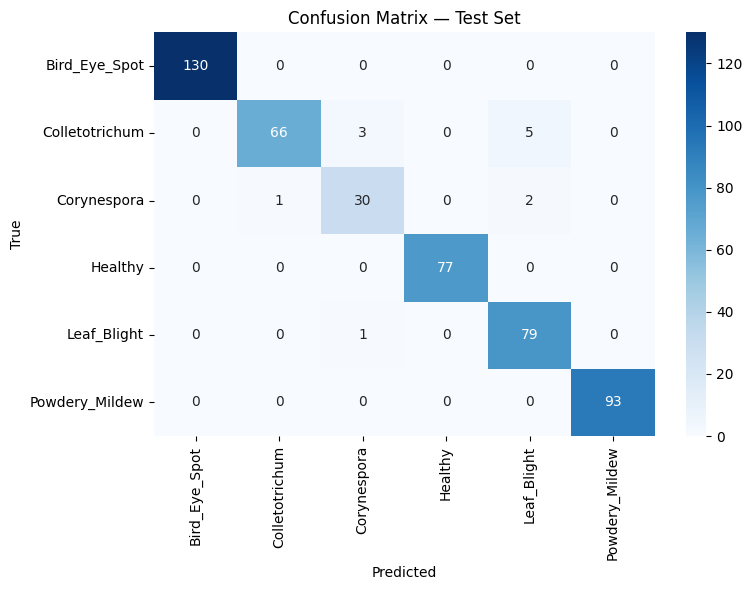

In [31]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=yolo_classes, yticklabels=yolo_classes, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout(); plt.show()

✅ Loaded 30 epochs of training data
   Columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

✅ Saved: runs\classify\runs\classify\rubber_yolo11m\training_curves.png
✅ Saved: runs\classify\runs\classify\rubber_yolo11m\training_curves.pdf


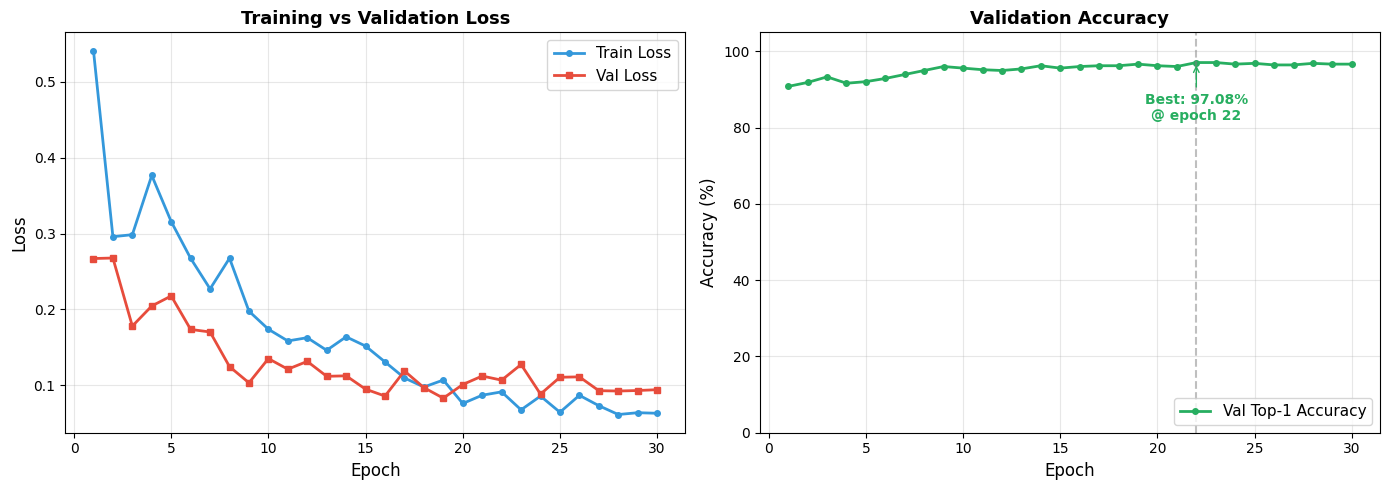

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Load the training results CSV (the missing piece) ─────────────
RESULTS_CSV = Path('runs/classify/runs/classify/rubber_yolo11m/results.csv')
assert RESULTS_CSV.exists(), f'❌ Not found: {RESULTS_CSV.resolve()}'

df = pd.read_csv(RESULTS_CSV)
df.columns = [c.strip() for c in df.columns]
print(f'✅ Loaded {len(df)} epochs of training data')
print(f'   Columns: {list(df.columns)}\n')

# ── Plot the standard training curves ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Loss curves (train vs val)
ax = axes[0]
ax.plot(df['epoch'], df['train/loss'], label='Train Loss',
        color='#3498db', linewidth=2, marker='o', markersize=4)
ax.plot(df['epoch'], df['val/loss'], label='Val Loss',
        color='#e74c3c', linewidth=2, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)

# RIGHT: Accuracy curve (val top-1)
ax = axes[1]
ax.plot(df['epoch'], df['metrics/accuracy_top1'] * 100,
        label='Val Top-1 Accuracy', color='#27ae60',
        linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

# Mark the best epoch
best_epoch = df['metrics/accuracy_top1'].idxmax()
best_acc = df['metrics/accuracy_top1'].iloc[best_epoch] * 100
ax.axvline(best_epoch + 1, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'Best: {best_acc:.2f}%\n@ epoch {best_epoch+1}',
            xy=(best_epoch + 1, best_acc),
            xytext=(best_epoch + 1, best_acc - 15),
            ha='center', fontsize=10, color='#27ae60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))

plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────
SAVE_DIR = Path('runs/classify/runs/classify/rubber_yolo11m')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.savefig(SAVE_DIR / 'training_curves.pdf', bbox_inches='tight')
print(f'✅ Saved: {SAVE_DIR / "training_curves.png"}')
print(f'✅ Saved: {SAVE_DIR / "training_curves.pdf"}')
plt.show()

---
## 🖼 Section 11 — Visualize Predictions

Sanity-check by looking at a few correct + incorrect predictions.

✅ Saved: runs\classify\runs\classify\rubber_yolo11m\sample_predictions.png


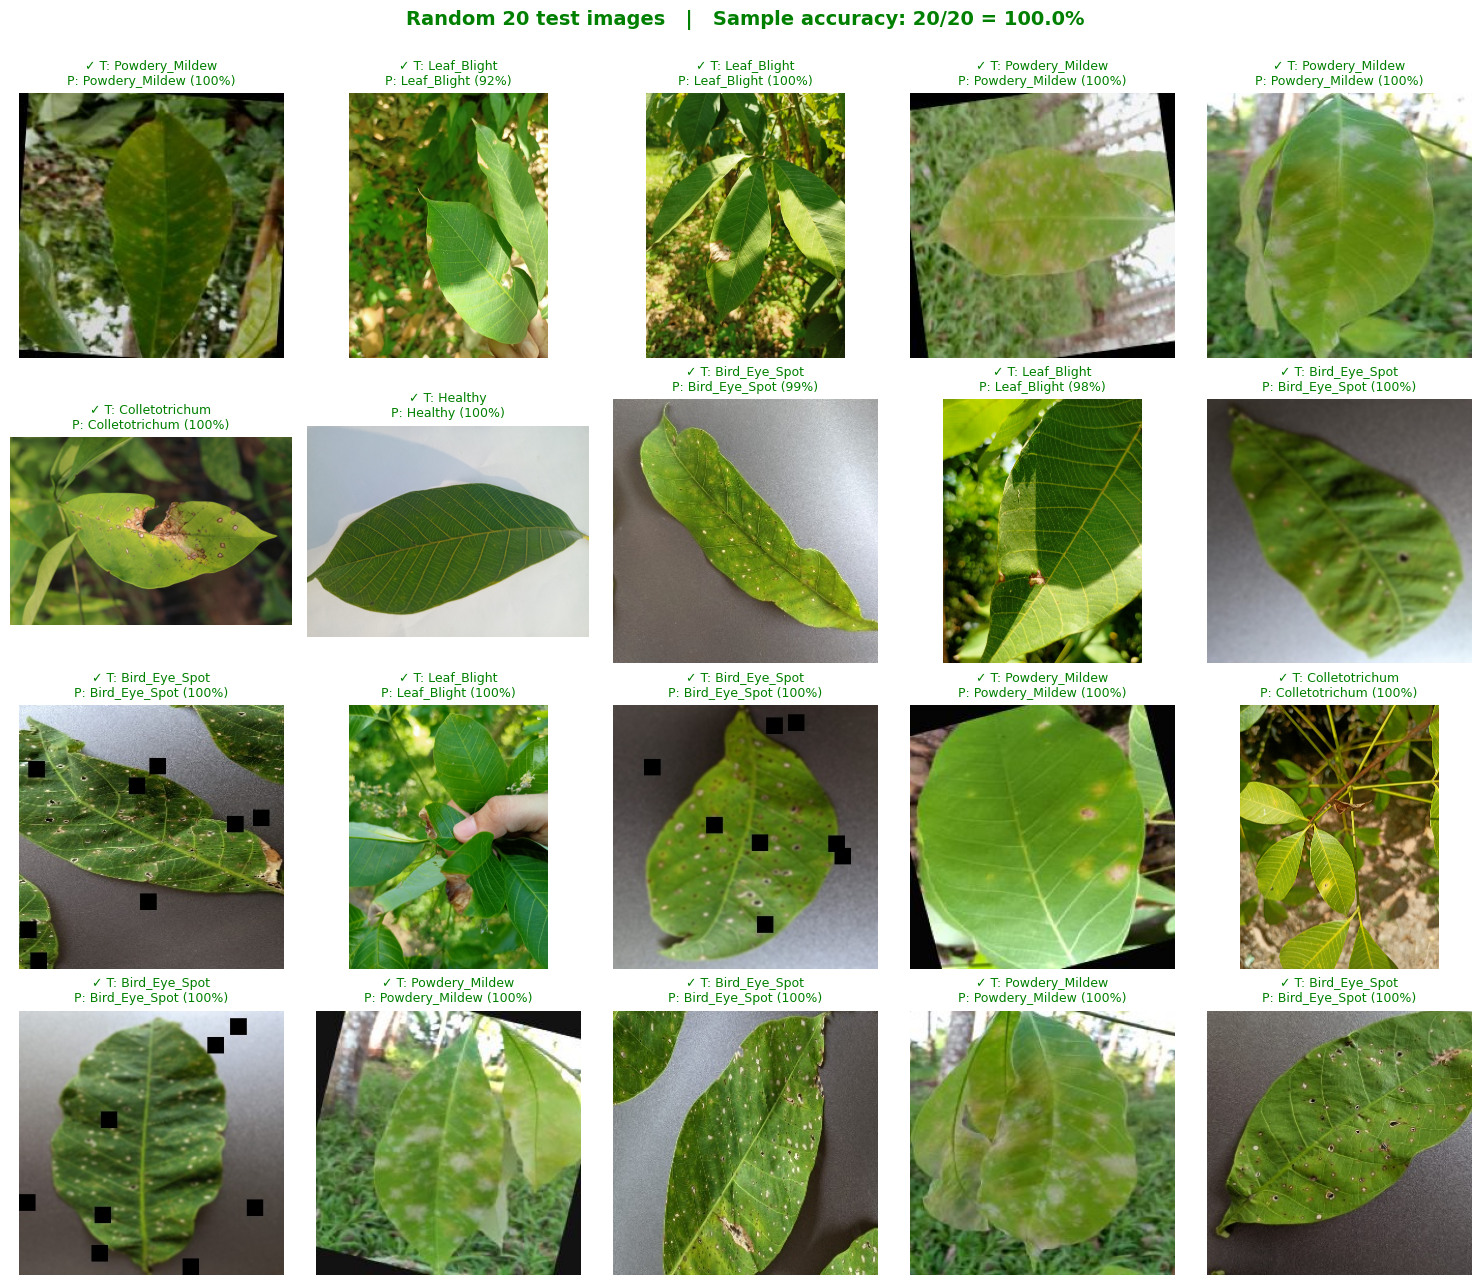

✅ Saved: runs\classify\runs\classify\rubber_yolo11m\per_class_accuracy.png


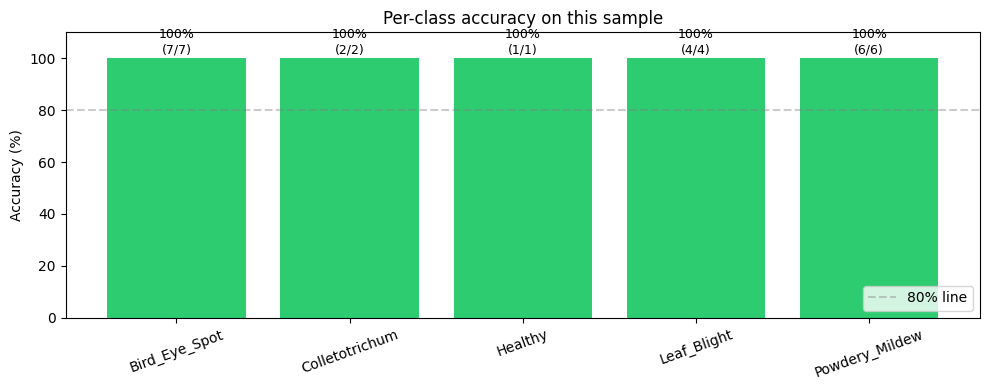


📊 Summary on 20-image random sample:
   Overall   : 20/20 = 100.0%

   Per class (only classes present in the sample):
     Bird_Eye_Spot      7/7 = 100.0%
     Colletotrichum     2/2 = 100.0%
     Healthy            1/1 = 100.0%
     Leaf_Blight        4/4 = 100.0%
     Powdery_Mildew     6/6 = 100.0%


In [33]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

# ── Settings ──────────────────────────────────────────────────────
N_SAMPLES = 20
GRID_COLS = 5
GRID_ROWS = 4   # 5 × 4 = 20

# ── 💾 Where to save outputs ──────────────────────────────────────
SAVE_DIR = Path('runs/classify/runs/classify/rubber_yolo11m')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Collect all test images with their true labels ────────────────
test_root = SPLIT_DIR / 'test'
all_test_imgs = []
for cls in CLASSES:
    for img_path in list_images(test_root / cls):
        all_test_imgs.append((img_path, cls))

# ── Pick N random images ──────────────────────────────────────────
N_SAMPLES = min(N_SAMPLES, len(all_test_imgs))
samples = random.sample(all_test_imgs, N_SAMPLES)

# ── Predict on all of them ────────────────────────────────────────
results_per_img = []
for img_path, true_label in samples:
    r = best_model.predict(str(img_path), imgsz=IMG_SIZE, verbose=False, device=DEVICE)[0]
    pred_name = yolo_classes[int(r.probs.top1)]
    pred_conf = float(r.probs.top1conf) * 100
    results_per_img.append({
        'path': img_path, 'true': true_label,
        'pred': pred_name, 'conf': pred_conf,
        'correct': pred_name == true_label,
    })

# ── Compute accuracies on this sample ─────────────────────────────
n_correct = sum(r['correct'] for r in results_per_img)
overall_acc = n_correct / N_SAMPLES * 100

per_class = defaultdict(lambda: {'correct': 0, 'total': 0})
for r in results_per_img:
    per_class[r['true']]['total']   += 1
    per_class[r['true']]['correct'] += int(r['correct'])

# ── Plot the grid ─────────────────────────────────────────────────
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(GRID_COLS*3, GRID_ROWS*3.2))

acc_color = 'green' if overall_acc >= 80 else ('orange' if overall_acc >= 60 else 'red')
fig.suptitle(f'Random {N_SAMPLES} test images   |   '
             f'Sample accuracy: {n_correct}/{N_SAMPLES} = {overall_acc:.1f}%',
             fontsize=14, fontweight='bold', color=acc_color, y=1.00)

for ax, r in zip(axes.flat, results_per_img):
    ax.imshow(Image.open(r['path']).convert('RGB'))
    ax.axis('off')
    color = 'green' if r['correct'] else 'red'
    mark  = '✓' if r['correct'] else '✗'
    ax.set_title(f'{mark} T: {r["true"]}\nP: {r["pred"]} ({r["conf"]:.0f}%)',
                 color=color, fontsize=9)

for ax in axes.flat[len(results_per_img):]:
    ax.axis('off')

plt.tight_layout()

# 💾 Save the sample-grid figure
plt.savefig(SAVE_DIR / 'sample_predictions.png', dpi=200, bbox_inches='tight')
plt.savefig(SAVE_DIR / 'sample_predictions.pdf', bbox_inches='tight')
print(f'✅ Saved: {SAVE_DIR / "sample_predictions.png"}')

plt.show()

# ── Per-class accuracy bar chart ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))
class_list = sorted(per_class.keys())
accs = [per_class[c]['correct'] / per_class[c]['total'] * 100 for c in class_list]
counts = [f"{per_class[c]['correct']}/{per_class[c]['total']}" for c in class_list]
colors2 = ['#2ecc71' if a >= 80 else ('#f39c12' if a >= 50 else '#e74c3c') for a in accs]

bars = ax2.bar(class_list, accs, color=colors2)
ax2.set_ylim(0, 110)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Per-class accuracy on this sample')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.4, label='80% line')
ax2.tick_params(axis='x', rotation=20)

for bar, acc, count in zip(bars, accs, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{acc:.0f}%\n({count})', ha='center', fontsize=9)

ax2.legend(loc='lower right')
plt.tight_layout()

# 💾 Save the per-class accuracy chart
plt.savefig(SAVE_DIR / 'per_class_accuracy.png', dpi=200, bbox_inches='tight')
plt.savefig(SAVE_DIR / 'per_class_accuracy.pdf', bbox_inches='tight')
print(f'✅ Saved: {SAVE_DIR / "per_class_accuracy.png"}')

plt.show()

# ── Summary print ────────────────────────────────────────────────
print(f'\n📊 Summary on {N_SAMPLES}-image random sample:')
print(f'   Overall   : {n_correct}/{N_SAMPLES} = {overall_acc:.1f}%')
print(f'\n   Per class (only classes present in the sample):')
for c in class_list:
    pc = per_class[c]
    print(f'     {c:18s} {pc["correct"]}/{pc["total"]} '
          f'= {pc["correct"]/pc["total"]*100:.1f}%')

---
## 📦 Section 12 — Export & Inference Demo

In [43]:
# Export to ONNX for deployment (optional — comment out if not needed)
best_model.export(format='onnx', imgsz=IMG_SIZE, dynamic=True)
print('✅ Exported to ONNX.')

Ultralytics 8.4.45  Python-3.11.15 torch-2.6.0+cu124 CPU (Intel Core 5 210H)

PyTorch: starting from 'runs\classify\runs\classify\rubber_yolo11m\weights\best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (19.9 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success  3.3s, saved as 'runs\classify\runs\classify\rubber_yolo11m\weights\best.onnx' (39.6 MB)

Export complete (4.1s)
Results saved to C:\Users\mohda\Documents\FYPProject\runs\classify\runs\classify\rubber_yolo11m\weights
Predict:         yolo predict task=classify model=runs\classify\runs\classify\rubber_yolo11m\weights\best.onnx imgsz=224 
Validate:        yolo val task=classify model=runs\classify\runs\classify\rubber_yolo11m\weights\best.onnx imgsz=224 data=C:\Users\mohda\Documents\FYPProject\Dataset_Split  
Visualize:       https://netron.app
✅ Exported to ONNX.


In [58]:
# Export only TFLite for Android + React Native
print('Exporting to TFLite...')
best_model.export(
    format='tflite',
    imgsz=IMG_SIZE,
    int8=False,      # set True later for ~4x smaller model (~10 MB) if you want
)
print('✅ TFLite export done.')

# Save class names alongside the model
import json
from pathlib import Path

weights_dir = Path('runs/classify/runs/classify/rubber_yolo11m/weights')
with open(weights_dir / 'classes.json', 'w') as f:
    json.dump(yolo_classes, f, indent=2)

print(f'\n📦 Files to ship in your RN app:')
for f in sorted(weights_dir.iterdir()):
    if f.suffix in ['.tflite', '.json']:
        size_mb = f.stat().st_size / 1e6
        print(f'   {f.name:30s} {size_mb:6.2f} MB')

Exporting to TFLite...


NameError: name 'best_model' is not defined

In [57]:
# Quick single-image inference example
sample = random.choice(list_images(SPLIT_DIR / 'test' / 'Healthy'))
result = best_model.predict(str(sample), imgsz=IMG_SIZE, verbose=False)[0]

print(f'Image      : {sample.name}')
print(f'True class : Healthy')
print(f'Predicted  : {yolo_classes[int(result.probs.top1)]} ({result.probs.top1conf*100:.2f}% confidence)')
print('\nTop-3 probabilities:')
top3 = result.probs.top5[:3]
top3_conf = result.probs.top5conf[:3]
for cls_idx, conf in zip(top3, top3_conf):
    print(f'   {yolo_classes[int(cls_idx)]:20s}  {float(conf)*100:6.2f}%')

plt.figure(figsize=(4, 4))
plt.imshow(Image.open(sample).convert('RGB')); plt.axis('off')
plt.title(f'Pred: {yolo_classes[int(result.probs.top1)]}'); plt.show()

NameError: name 'random' is not defined

📂 Loading model: best.onnx
   Provider : CPUExecutionProvider
   Input    : images  shape=[1, 3, 224, 224]
   Output   : output0 shape=[1, 6]

🖼  Loading image: bird_eye_spot2.png
   Original size : (419, 402)
   Input tensor  : (1, 3, 224, 224)  dtype=float32

══════════════════════════════════════════════════
🎯 PREDICTION: Bird_Eye_Spot  (99.64%)
⚡ Inference time: 237.1 ms
══════════════════════════════════════════════════

All class probabilities:
   Bird_Eye_Spot       99.64%  █████████████████████████████
   Colletotrichum       0.28%  
   Healthy              0.09%  
   Corynespora          0.00%  
   Leaf_Blight          0.00%  
   Powdery_Mildew       0.00%  

✅ Strong prediction — model is confident.


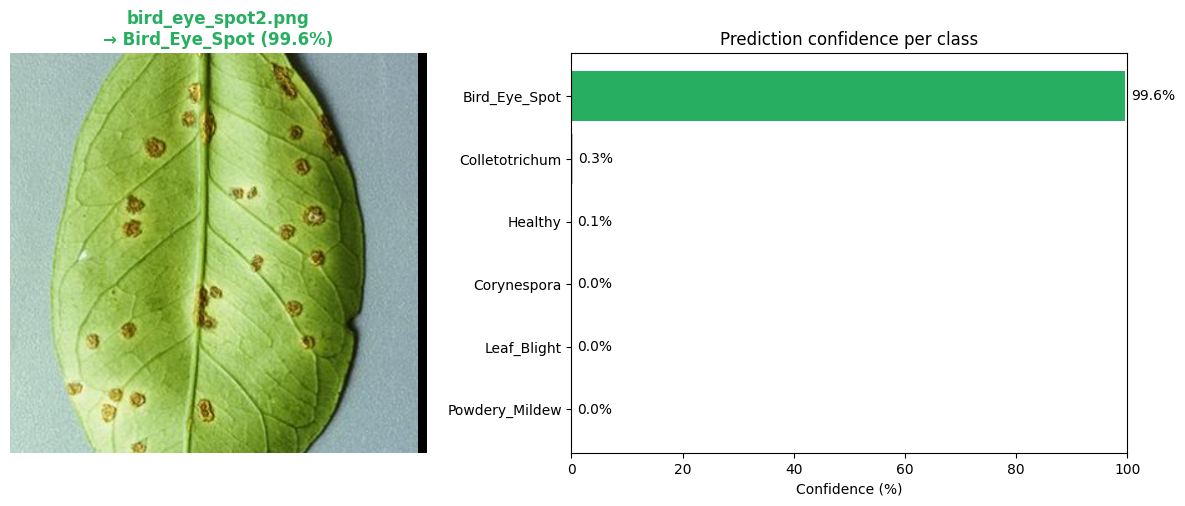

In [15]:
import json
import time
from pathlib import Path
import numpy as np
import onnxruntime as ort
from PIL import Image
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════
# 👇 EDIT THESE TWO PATHS
# ═══════════════════════════════════════════════════════════════════
IMAGE_PATH = Path('bird_eye_spot2.png')   # 👈 change to your image filename/path
ONNX_PATH  = Path('runs/classify/runs/classify/rubber_yolo11m/weights/best.onnx')

# ── Other config (usually no need to edit) ────────────────────────
IMG_SIZE = 224
CLASSES = ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora',
           'Healthy', 'Leaf_Blight', 'Powdery_Mildew']

# ── Sanity checks ─────────────────────────────────────────────────
assert IMAGE_PATH.exists(), f'❌ Image not found: {IMAGE_PATH.resolve()}'
assert ONNX_PATH.exists(),  f'❌ Model not found: {ONNX_PATH.resolve()}'

# ── Load ONNX model (only once — cached if you re-run) ────────────
if 'session' not in globals():
    print(f'📂 Loading model: {ONNX_PATH.name}')
    session = ort.InferenceSession(
        str(ONNX_PATH),
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    INPUT_NAME  = session.get_inputs()[0].name
    OUTPUT_NAME = session.get_outputs()[0].name
    print(f'   Provider : {session.get_providers()[0]}')
    print(f'   Input    : {INPUT_NAME}  shape={session.get_inputs()[0].shape}')
    print(f'   Output   : {OUTPUT_NAME} shape={session.get_outputs()[0].shape}')

# ── Preprocess image ──────────────────────────────────────────────
print(f'\n🖼  Loading image: {IMAGE_PATH.name}')
img = Image.open(IMAGE_PATH).convert('RGB')
print(f'   Original size : {img.size}')

img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
arr = np.array(img_resized, dtype=np.float32) / 255.0     # HWC, [0,1]
arr = arr.transpose(2, 0, 1)                              # CHW
arr = np.expand_dims(arr, axis=0)                         # NCHW
print(f'   Input tensor  : {arr.shape}  dtype={arr.dtype}')

# ── Run inference ─────────────────────────────────────────────────
t0 = time.time()
outputs = session.run([OUTPUT_NAME], {INPUT_NAME: arr})
inference_ms = (time.time() - t0) * 1000

probs = outputs[0][0]   # shape (6,) — one prob per class

# ── Rank predictions ──────────────────────────────────────────────
ranked = sorted(
    [(CLASSES[i], float(probs[i])) for i in range(len(probs))],
    key=lambda x: -x[1]
)
top_name, top_conf = ranked[0]

# ── Print results ─────────────────────────────────────────────────
print('\n' + '═' * 50)
print(f'🎯 PREDICTION: {top_name}  ({top_conf*100:.2f}%)')
print(f'⚡ Inference time: {inference_ms:.1f} ms')
print('═' * 50)
print('\nAll class probabilities:')
for name, prob in ranked:
    bar = '█' * int(prob * 30)
    print(f'   {name:18s} {prob*100:6.2f}%  {bar}')

print()
if top_conf >= 0.85:
    print('✅ Strong prediction — model is confident.')
elif top_conf >= 0.60:
    print('🟡 Moderate prediction — second-best class is also worth considering.')
else:
    print('⚠️  Low confidence — image may be unclear or unfamiliar to the model.')

# ── Visualize ─────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.3]})

ax_img.imshow(img); ax_img.axis('off')
title_color = '#27ae60' if top_conf > 0.7 else '#e67e22'
ax_img.set_title(f'{IMAGE_PATH.name}\n→ {top_name} ({top_conf*100:.1f}%)',
                 fontsize=12, fontweight='bold', color=title_color)

names = [r[0] for r in ranked]
percs = [r[1] * 100 for r in ranked]
colors = ['#27ae60' if i == 0 else '#bdc3c7' for i in range(len(names))]
bars = ax_bar.barh(names, percs, color=colors)
ax_bar.invert_yaxis()
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Prediction confidence per class')
for bar, p in zip(bars, percs):
    ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{p:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Convert into Tflite for mobile app 

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Export TFLite model alongside existing ONNX (best.pt → best.tflite)
# Your existing best.onnx is NOT touched.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
from ultralytics import YOLO

# ── Re-declare variables (since kernel was restarted) ─────────────
BEST_PT  = Path('runs/classify/runs/classify/rubber_yolo11m/weights/best.pt')
IMG_SIZE = 224

assert BEST_PT.exists(), f'❌ Model not found: {BEST_PT.resolve()}'
print(f'📂 Loading: {BEST_PT.resolve()}')

model = YOLO(str(BEST_PT))

# ── Export to TFLite (this creates new files; ONNX stays untouched) ──
print('\n🔄 Exporting to TFLite (this takes 2-5 minutes)...')
tflite_path = model.export(
    format = 'tflite',
    imgsz  = IMG_SIZE,
    int8   = False,   # set True later if you want a smaller model (~10 MB)
)
print(f'\n✅ TFLite export complete!')
print(f'   File: {tflite_path}')

# ── Verify both formats exist ─────────────────────────────────────
weights_dir = BEST_PT.parent
print('\n📦 All exported model files:')
for f in sorted(weights_dir.glob('*')):
    size_mb = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f'   {f.name:35s} {size_mb:7.2f} MB')

📂 Loading: C:\Users\mohda\Documents\FYPProject\runs\classify\runs\classify\rubber_yolo11m\weights\best.pt

🔄 Exporting to TFLite (this takes 2-5 minutes)...
Ultralytics 8.4.45  Python-3.11.15 torch-2.6.0+cu124 CPU (Intel Core 5 210H)
YOLO11m-cls summary (fused): 57 layers, 10,349,318 parameters, 0 gradients, 39.3 GFLOPs

PyTorch: starting from 'runs\classify\runs\classify\rubber_yolo11m\weights\best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (19.9 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success  7.1s, saved as 'runs\classify\runs\classify\rubber_yolo11m\weights\best.onnx' (39.5 MB)
requirements: Ultralytics requirement ['tf_keras<=2.19.0'] not found, attempting AutoUpdate...
Using Python 3.11.15 environment at: C:\Users\mohda\.conda\envs\rubber-disease
Resolved 39 packages in 14.63s
Prepared 1 package in 1.29s
Installed 1 package in 817ms
 + tf-keras==2.19.0

requirements: AutoUpdate success 


🖼  Loading image: cor1.png
   Original size: (316, 239)
   Input tensor : (1, 224, 224, 3)  dtype=float32

══════════════════════════════════════════════════
🎯 PREDICTION: Corynespora  (91.38%)
⚡ Inference time: 664.2 ms
══════════════════════════════════════════════════

All class probabilities:
   Corynespora         91.38%  ███████████████████████████
   Bird_Eye_Spot        8.54%  ██
   Leaf_Blight          0.05%  
   Healthy              0.03%  
   Colletotrichum       0.00%  
   Powdery_Mildew       0.00%  

✅ Strong prediction — model is confident.


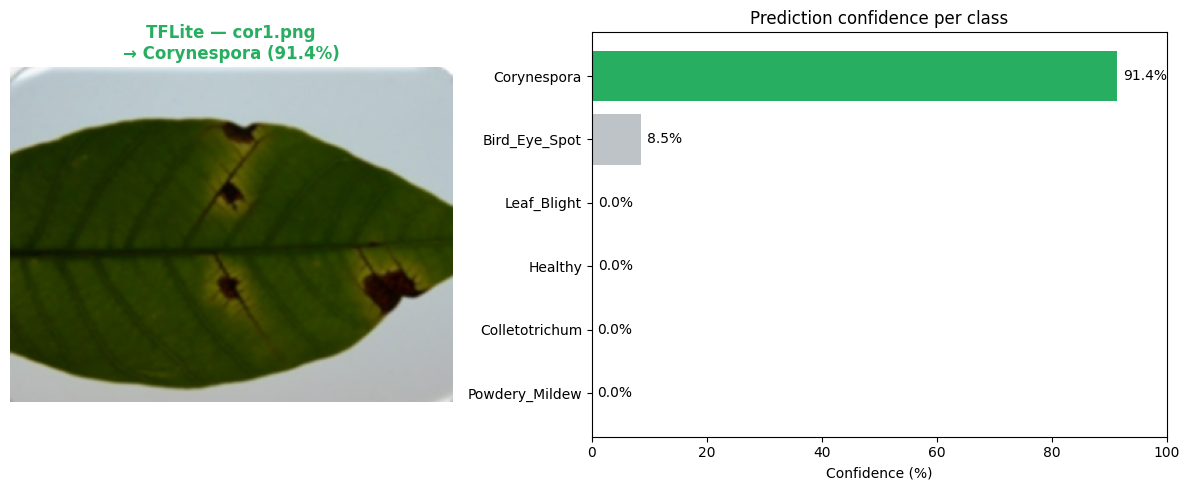

In [14]:
import time
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════
# 👇 EDIT THIS
# ═══════════════════════════════════════════════════════════════════
IMAGE_PATH  = Path('cor1.png')   # 👈 change to your image filename
TFLITE_PATH = Path('runs/classify/runs/classify/rubber_yolo11m/weights/best_saved_model/best_float32.tflite')


# ── Other config (usually no need to edit) ────────────────────────
IMG_SIZE = 224
CLASSES = ['Bird_Eye_Spot', 'Colletotrichum', 'Corynespora',
           'Healthy', 'Leaf_Blight', 'Powdery_Mildew']

# ── Sanity checks ─────────────────────────────────────────────────
assert IMAGE_PATH.exists(),  f'❌ Image not found: {IMAGE_PATH.resolve()}'
assert TFLITE_PATH.exists(), f'❌ TFLite not found: {TFLITE_PATH.resolve()}'

# ── Load TFLite interpreter (cached if you re-run) ────────────────
if 'interpreter' not in globals():
    print(f'📂 Loading model: {TFLITE_PATH.name}')
    try:
        from ai_edge_litert.interpreter import Interpreter
    except ImportError:
        from tensorflow.lite.python.interpreter import Interpreter
    
    interpreter = Interpreter(model_path=str(TFLITE_PATH))
    interpreter.allocate_tensors()
    INPUT_DETAILS  = interpreter.get_input_details()[0]
    OUTPUT_DETAILS = interpreter.get_output_details()[0]
    
    print(f'   Input shape : {INPUT_DETAILS["shape"]}  dtype={INPUT_DETAILS["dtype"].__name__}')
    print(f'   Output shape: {OUTPUT_DETAILS["shape"]}')

# ── Preprocess image ──────────────────────────────────────────────
print(f'\n🖼  Loading image: {IMAGE_PATH.name}')
img = Image.open(IMAGE_PATH).convert('RGB')
print(f'   Original size: {img.size}')

img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
arr = np.array(img_resized, dtype=np.float32) / 255.0   # HWC, [0,1]

# Auto-detect input layout: CHW vs HWC
if INPUT_DETAILS['shape'][1] == 3:    # [1, 3, 224, 224] = CHW
    arr = arr.transpose(2, 0, 1)
arr = np.expand_dims(arr, axis=0).astype(INPUT_DETAILS['dtype'])
print(f'   Input tensor : {arr.shape}  dtype={arr.dtype}')

# ── Run inference ─────────────────────────────────────────────────
t0 = time.time()
interpreter.set_tensor(INPUT_DETAILS['index'], arr)
interpreter.invoke()
probs = interpreter.get_tensor(OUTPUT_DETAILS['index'])[0]
inference_ms = (time.time() - t0) * 1000

# ── Rank predictions ──────────────────────────────────────────────
ranked = sorted(
    [(CLASSES[i], float(probs[i])) for i in range(len(probs))],
    key=lambda x: -x[1]
)
top_name, top_conf = ranked[0]

# ── Print results ─────────────────────────────────────────────────
print('\n' + '═' * 50)
print(f'🎯 PREDICTION: {top_name}  ({top_conf*100:.2f}%)')
print(f'⚡ Inference time: {inference_ms:.1f} ms')
print('═' * 50)
print('\nAll class probabilities:')
for name, prob in ranked:
    bar = '█' * int(prob * 30)
    print(f'   {name:18s} {prob*100:6.2f}%  {bar}')

print()
if top_conf >= 0.85:
    print('✅ Strong prediction — model is confident.')
elif top_conf >= 0.60:
    print('🟡 Moderate prediction — second-best class is also worth considering.')
else:
    print('⚠️  Low confidence — image may be unclear or unfamiliar to the model.')

# ── Visualize ─────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.3]})

ax_img.imshow(img); ax_img.axis('off')
title_color = '#27ae60' if top_conf > 0.7 else '#e67e22'
ax_img.set_title(f'TFLite — {IMAGE_PATH.name}\n→ {top_name} ({top_conf*100:.1f}%)',
                 fontsize=12, fontweight='bold', color=title_color)

names = [r[0] for r in ranked]
percs = [r[1] * 100 for r in ranked]
colors = ['#27ae60' if i == 0 else '#bdc3c7' for i in range(len(names))]
bars = ax_bar.barh(names, percs, color=colors)
ax_bar.invert_yaxis()
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Prediction confidence per class')
for bar, p in zip(bars, percs):
    ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{p:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 🎓 Final Notes

**To resume training after a crash:** just run Section 8 then Section 9 again. The notebook detects `last.pt` and continues automatically.

**If accuracy is still low on a specific class** (visible in the confusion matrix and classification report):
- That class likely needs more raw images, or
- That class has visually similar samples to another class — collect harder examples

**To push accuracy higher** (after this 30-min run works):
1. Increase `EPOCHS` to 100 in Section 2 — re-run, it will resume
2. Try `MODEL_NAME = 'yolo11l-cls.pt'` (large) — needs more VRAM but +1–2% accuracy
3. Increase `IMG_SIZE` to 320 or 384 — better for HD images, slower training

**Files produced:**
- `runs/classify/rubber_yolo11m/weights/best.pt` — your trained model
- `runs/classify/rubber_yolo11m/weights/best.onnx` — for deployment
- `runs/classify/rubber_yolo11m_test_eval/` — test set evaluation plots